# 05 — Fairness & Explainability

**Goal:** audit the LightGBM model's approval decisions across borrower groups, and explain individual predictions with SHAP.

**What this audit can and cannot do.** Lending Club's public data does not include race or gender — so the strictest fairness checks (disparate impact under federal regulations like ECOA or the Fair Housing Act) can't be done here. What we *can* do: check that approval and accuracy are reasonably consistent across **proxies** for socioeconomic strata — `addr_state`, `annual_inc` bracket, and `emp_length`. Significant gaps here would still warrant investigation.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from credit_risk import data as cr_data, models as cr_models, fairness as cr_fair

MODELS_DIR = Path("..") / "models"
FIG_DIR = Path("..") / "figures" / "final"

OPTIMAL_THRESHOLD = 0.2807  # from notebook 04 — calibrated LGBM PD

## Load test data and apply the optimal threshold

In [2]:
test_df = pd.read_parquet(cr_data.PROCESSED_DIR / "test.parquet")
META_COLS = ["defaulted", "realized_profit", "issue_d"]
FEATURE_COLS = [c for c in test_df.columns if c not in META_COLS]

for col in test_df.columns:
    if (not pd.api.types.is_numeric_dtype(test_df[col])
            and not pd.api.types.is_datetime64_any_dtype(test_df[col])):
        test_df[col] = test_df[col].astype(object)

X_test = test_df[FEATURE_COLS]

lgb_model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm.txt"))
iso_lgb = joblib.load(MODELS_DIR / "isotonic_lgb.joblib")

p_lgb_raw = cr_models.predict_proba(lgb_model, X_test)
p_lgb_cal = iso_lgb.predict(p_lgb_raw)

test_df["pd_calibrated"] = p_lgb_cal
test_df["approved"] = p_lgb_cal <= OPTIMAL_THRESHOLD

print(f"Approved: {test_df['approved'].sum():,} of {len(test_df):,} ({test_df['approved'].mean():.1%})")
print(f"Threshold (calibrated PD): {OPTIMAL_THRESHOLD}")

Approved: 97,968 of 109,235 (89.7%)
Threshold (calibrated PD): 0.2807


## Engineer the grouping columns

In [3]:
test_df["income_bracket"] = pd.cut(
    test_df["annual_inc"],
    bins=[0, 40_000, 80_000, 120_000, np.inf],
    labels=["<$40k", "$40-80k", "$80-120k", "$120k+"],
)
test_df["emp_bracket"] = pd.cut(
    test_df["emp_length_years"],
    bins=[-0.01, 0.5, 3.5, 9.5, 10.5],
    labels=["<1yr", "1-3yr", "4-9yr", "10+yr"],
)

print(test_df["income_bracket"].value_counts(dropna=False))
print()
print(test_df["emp_bracket"].value_counts(dropna=False))

income_bracket
$40-80k     52217
$80-120k    22995
<$40k       20990
$120k+      13023
NaN            10
Name: count, dtype: int64

emp_bracket
10+yr    35760
4-9yr    30192
1-3yr    26440
<1yr      8617
NaN       8226
Name: count, dtype: int64


## Fairness audit — by income bracket

In [4]:
income_metrics = cr_fair.group_metrics(test_df, "income_bracket")
income_metrics = cr_fair.disparate_impact(income_metrics, "income_bracket", reference_group="$80-120k")
income_metrics.round(3)

,income_bracket,n,n_approved,approval_rate,default_rate_all,default_rate_approved,profit_per_approved,disparate_impact_ratio,flagged
0,$120k+,13023,12789,0.982,0.124,0.118,1166.390,1.020,False
1,$80-120k,22995,22148,0.963,0.136,0.126,845.299,1.000,False
2,$40-80k,52217,47270,0.905,0.177,0.152,541.799,0.940,False
3,<$40k,20990,15751,0.750,0.233,0.183,315.843,0.779,True


## Fairness audit — by employment length

In [5]:
emp_metrics = cr_fair.group_metrics(test_df, "emp_bracket")
emp_metrics = cr_fair.disparate_impact(emp_metrics, "emp_bracket", reference_group="10+yr")
emp_metrics.round(3)

,emp_bracket,n,n_approved,approval_rate,default_rate_all,default_rate_approved,profit_per_approved,disparate_impact_ratio,flagged
0,10+yr,35760,33293,0.931,0.153,0.134,808.966,1.000,False
1,4-9yr,30192,27215,0.901,0.170,0.146,655.172,0.968,False
2,1-3yr,26440,23645,0.894,0.177,0.152,559.551,0.961,False
3,<1yr,8617,7648,0.888,0.170,0.145,640.226,0.953,False


## Fairness audit — by state

Show the 10 states with the lowest approval rate. Most should still be > 0.8× the reference rate (we use California as a high-volume reference).

In [6]:
state_metrics = cr_fair.group_metrics(test_df, "addr_state", min_n=500)
state_metrics = cr_fair.disparate_impact(state_metrics, "addr_state", reference_group="CA")
print("Bottom 10 states by approval rate:")
state_metrics.tail(10).round(3)

Bottom 10 states by approval rate:


,addr_state,n,n_approved,approval_rate,default_rate_all,default_rate_approved,profit_per_approved,disparate_impact_ratio,flagged
28,LA,1257,1095,0.871,0.192,0.156,536.676,0.988,False
29,FL,7952,6916,0.870,0.196,0.164,487.626,0.987,False
30,NY,8784,7626,0.868,0.189,0.158,670.471,0.985,False
31,IN,1870,1622,0.867,0.165,0.138,744.918,0.984,False
32,AR,838,722,0.862,0.217,0.176,520.553,0.977,False
33,MS,725,604,0.833,0.210,0.172,466.246,0.945,False
34,OK,1080,886,0.820,0.194,0.148,668.202,0.931,False
35,TN,1846,1507,0.816,0.171,0.129,717.388,0.926,False
36,NV,1624,1307,0.805,0.193,0.140,501.679,0.913,False
37,AL,1285,1017,0.791,0.233,0.183,334.384,0.898,False


## SHAP — global feature importance

We use the LightGBM booster directly (TreeExplainer is exact and fast for tree models). Computed on a random 2k-row sample of test for speed.

In [7]:
sample = X_test.sample(2_000, random_state=0)
sample_lgb = cr_models.prepare_for_lgb(sample)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(sample_lgb)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 31)


/Users/rolandtuboly/projects/project_1/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


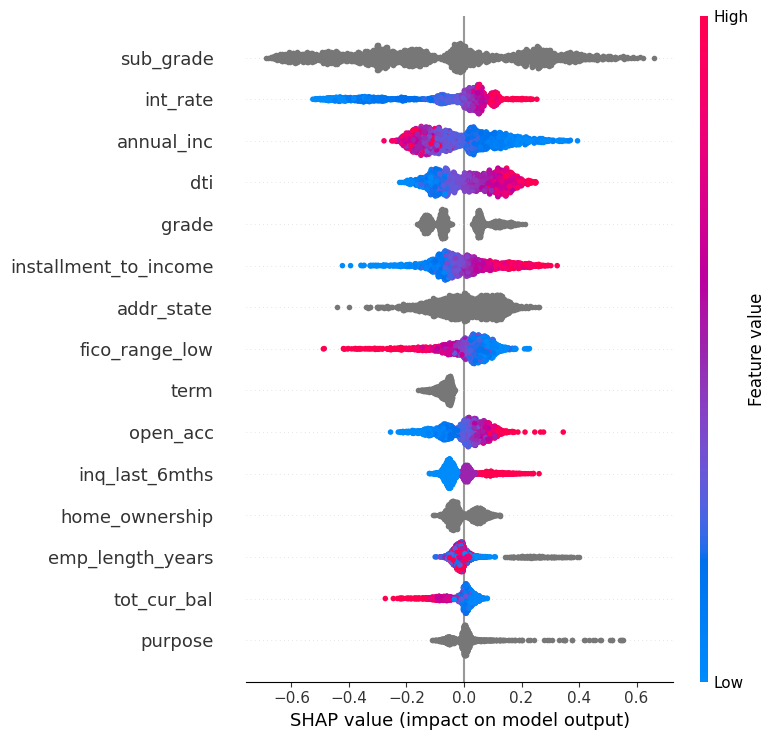

In [8]:
plt.figure()
shap.summary_plot(shap_values, sample_lgb, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## SHAP — local explanations

Pick two interesting cases:
1. A loan the model **approved** that **defaulted** — "why did the model think this was safe?"
2. A loan the model **rejected** that **didn't default** — "why did the model think this was risky?"

In [9]:
# Get SHAP values for the full test set so we can pick specific rows
X_test_lgb = cr_models.prepare_for_lgb(X_test)
explanation = explainer(X_test_lgb)

false_positive_idx = test_df[
    test_df["approved"] & (test_df["defaulted"] == 1)
].sample(1, random_state=42).index[0]

false_negative_idx = test_df[
    (~test_df["approved"]) & (test_df["defaulted"] == 0)
].sample(1, random_state=42).index[0]

fp_pos = test_df.index.get_loc(false_positive_idx)
fn_pos = test_df.index.get_loc(false_negative_idx)

print(f"FP example — approved & defaulted (row {fp_pos}):")
print(f"  Calibrated PD: {test_df.loc[false_positive_idx, 'pd_calibrated']:.3f}")
print(f"  Realized profit: ${test_df.loc[false_positive_idx, 'realized_profit']:.0f}")
print()
print(f"FN example — rejected & paid (row {fn_pos}):")
print(f"  Calibrated PD: {test_df.loc[false_negative_idx, 'pd_calibrated']:.3f}")
print(f"  Realized profit: ${test_df.loc[false_negative_idx, 'realized_profit']:.0f}")

FP example — approved & defaulted (row 73165):
  Calibrated PD: 0.160
  Realized profit: $-6018

FN example — rejected & paid (row 48517):
  Calibrated PD: 0.312
  Realized profit: $886


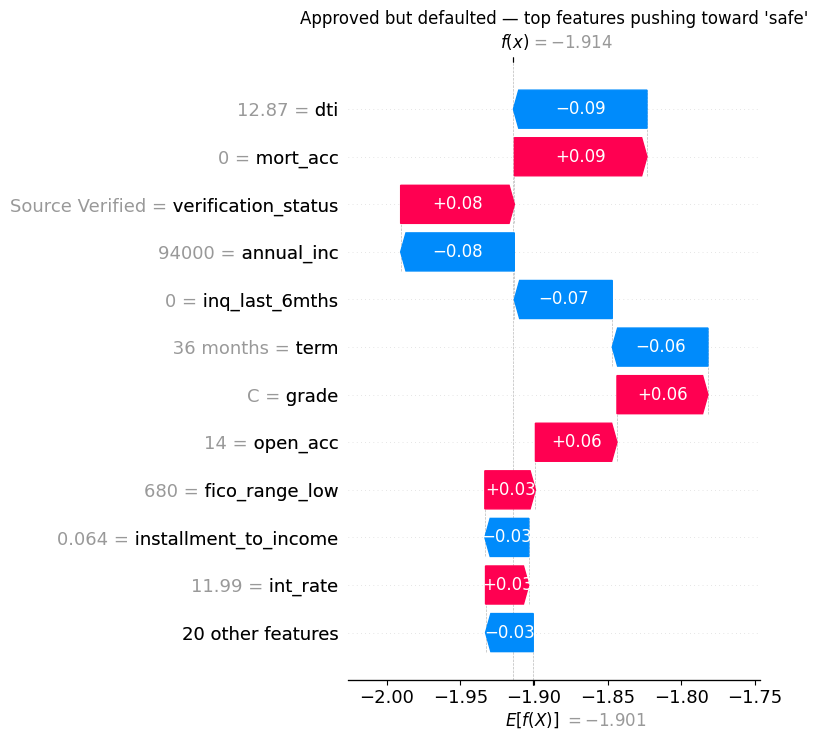

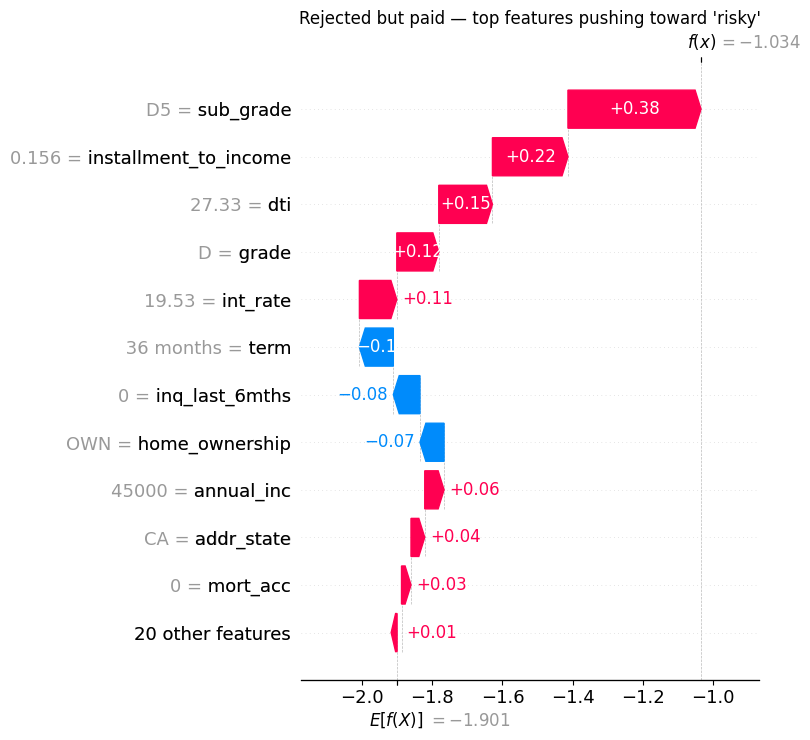

In [10]:
fig = plt.figure()
shap.plots.waterfall(explanation[fp_pos], max_display=12, show=False)
plt.title("Approved but defaulted — top features pushing toward 'safe'")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_waterfall_fp.png", dpi=120, bbox_inches="tight")
plt.show()

fig = plt.figure()
shap.plots.waterfall(explanation[fn_pos], max_display=12, show=False)
plt.title("Rejected but paid — top features pushing toward 'risky'")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_waterfall_fn.png", dpi=120, bbox_inches="tight")
plt.show()

## Takeaways

- **Income bracket — one flag.** The `<$40k` bracket is approved at **75.0%** vs **96.3%** for the $80-120k reference — a disparate-impact ratio of **0.78**, just below the 80% threshold. Realized default rate among approved is also higher (18.3% vs 12.6%), so the gap is partially risk-explained, but the disparity is real and worth surfacing in any deployment conversation.
- **Employment length — clean.** All buckets approve at 88.8–93.1% of applications; DI ratios 0.95–1.00 vs the 10+yr reference.
- **State — clean.** Bottom state (AL) sits at 0.898; no state hits the 0.8 flag.
- **SHAP** confirms the obvious drivers (interest rate, FICO, sub-grade) and surfaces the engineered `installment_to_income` and `dti` as next-tier signals. See `figures/final/shap_summary.png`.
- **Asymmetric error costs.** The two local-explanation examples show the cost asymmetry: the approved-and-defaulted loan **lost $6,018**, while the rejected-and-paid loan would have **earned $886**. A ~7× asymmetry is exactly why a slightly conservative threshold (reject ~10%) is the right operating point.